In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_PATH = "./data/World-happiness-report-2024.csv"

def read_csv_data(data_path):
    """
    Lee un archivo csv y retorna un dataframe
    Args:
        data_path: str, ruta del archivo csv
    Returns:
        df: pd.DataFrame, dataframe con los datos del archivo csv
    """
    # Si la ruta del archivo está vacía, retorna None
    if data_path is None or len(data_path) == 0:
        print("La ruta del archivo está vacía")
        return None
    
    try:
        df = pd.read_csv(data_path)
        return df
    except FileNotFoundError:
        # Si el archivo no se encuentra, retorna None
        print(f"No se pudo encontrar el archivo en la ruta: {data_path}")
        return None
    except Exception as e:
        # Si ocurre un error, retorna None
        print(f"Error al leer el archivo: {e}")
        return None

def clean_data(df):
    if df is None or df.empty:
        print("El dataframe está vacío o es None")
        return None
    
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    df = df.dropna()
    df = df.drop_duplicates()
    return df

def change_data_type(df, column_names: list[str], new_type):
    if df is None or df.empty:
        print("El dataframe está vacío o es None")
        return None
    
    if column_names is None or len(column_names) == 0:
        print("La lista de columnas está vacía")
        return df
    
    if new_type is None or len(new_type) == 0:
        print("El tipo de datos está vacío")
        return df
    
    for column in column_names:
        if column in df.columns:
            df[column] = df[column].astype(new_type)
        else:
            print(f"La columna '{column}' no existe en el dataframe")
    return df

df = read_csv_data(DATA_PATH)
df = clean_data(df)
df = change_data_type(df, ['country_name', 'regional_indicator'], 'string')
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country_name                  140 non-null    string 
 1   regional_indicator            140 non-null    string 
 2   ladder_score                  140 non-null    float64
 3   upperwhisker                  140 non-null    float64
 4   lowerwhisker                  140 non-null    float64
 5   log_gdp_per_capita            140 non-null    float64
 6   social_support                140 non-null    float64
 7   healthy_life_expectancy       140 non-null    float64
 8   freedom_to_make_life_choices  140 non-null    float64
 9   generosity                    140 non-null    float64
 10  perceptions_of_corruption     140 non-null    float64
 11  dystopia_+_residual           140 non-null    float64
dtypes: float64(10), string(2)
memory usage: 14.2 KB
None
  country_name  

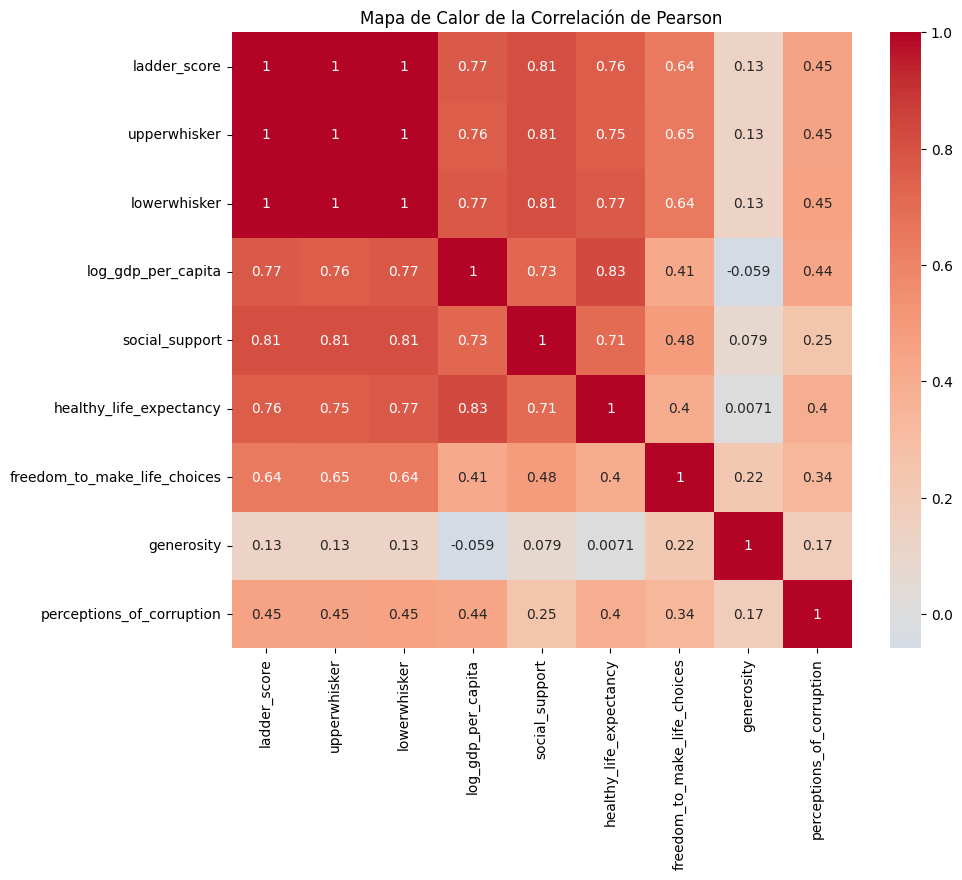

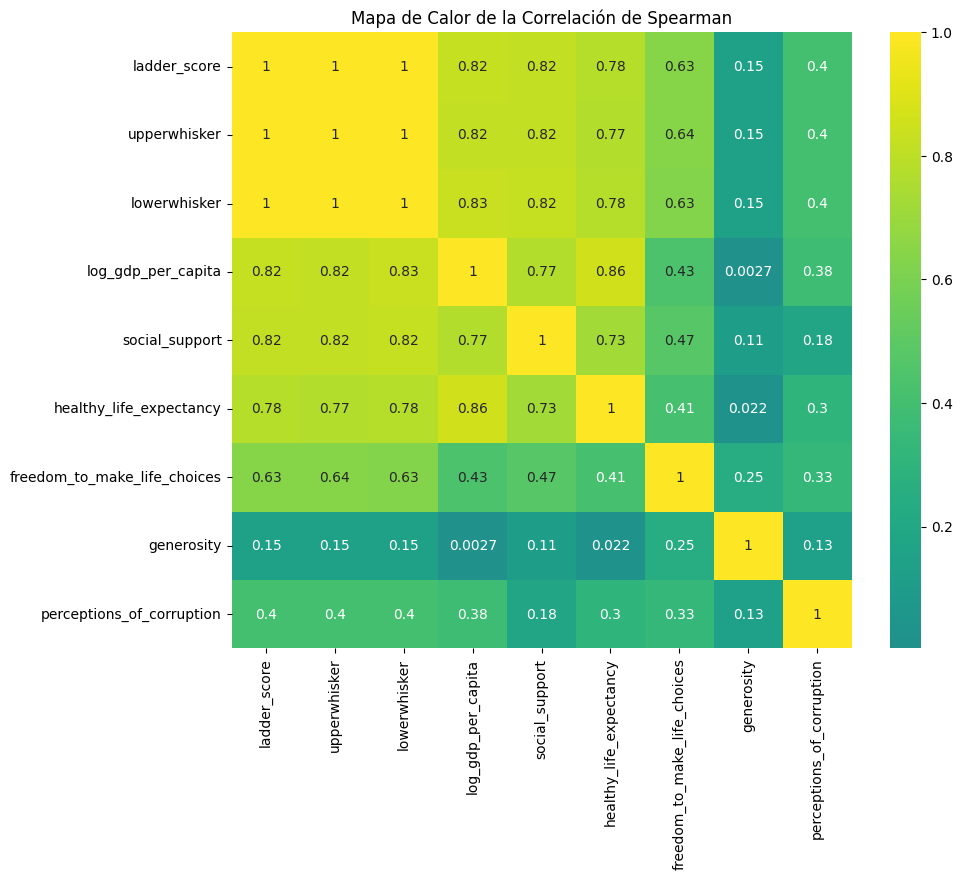

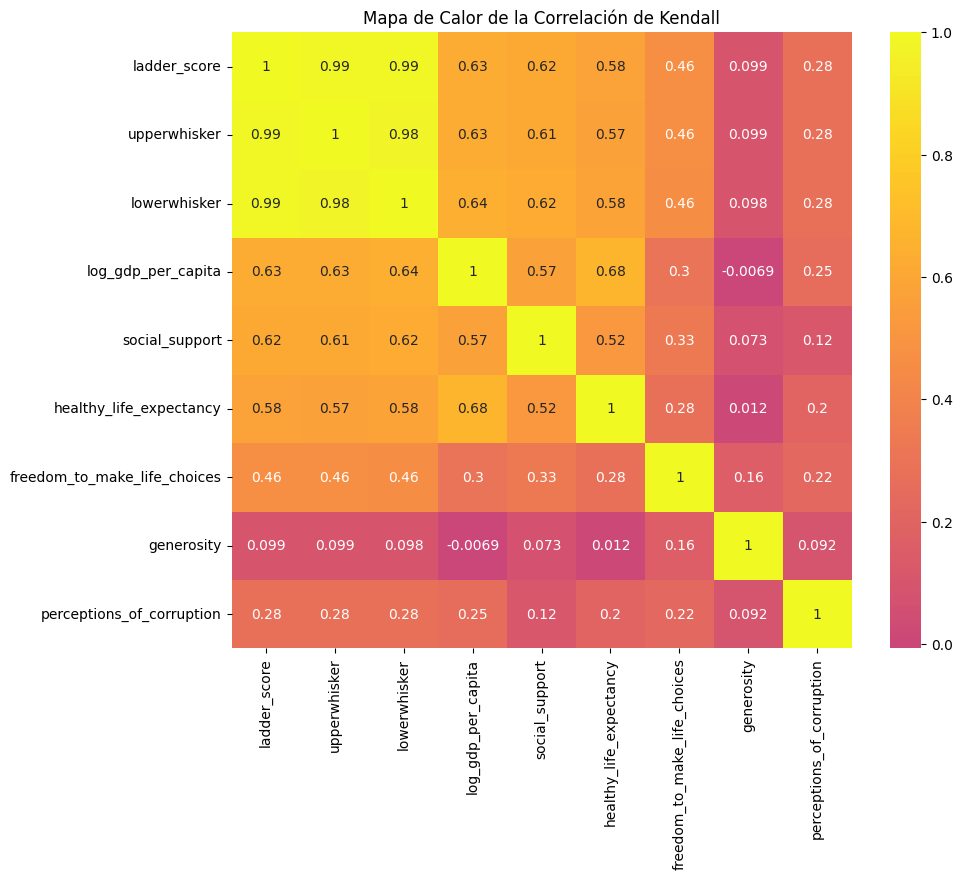

In [12]:
# Calcular las correlaciones
df = df[['ladder_score', 'upperwhisker', 'lowerwhisker', 'log_gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom_to_make_life_choices', 'generosity', 'perceptions_of_corruption']]
correlation_matrix = df.corr(method='pearson')
spearman_corr = df.corr(method='spearman')
kendall_corr = df.corr(method='kendall')

# Crear mapas de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Mapa de Calor de la Correlación de Pearson")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='viridis', center=0)
plt.title("Mapa de Calor de la Correlación de Spearman")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(kendall_corr, annot=True, cmap='plasma', center=0)
plt.title("Mapa de Calor de la Correlación de Kendall")
plt.show()